In [13]:
from sklearn import set_config

set_config(display="text")

#### Load dataset

In [14]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

In [15]:
list(zip(X, y))[0]

(array([1.4, 0.2]), np.int64(0))

In [16]:
print("Class label: ", np.unique(y))

Class label:  [0 1 2]


#### Split training-test set

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state= 1, stratify= y
)

# Stratify = y : 전체 데이터 셋에서 각 라벨에 속하는 데이터의 비율이 Training set과 Test set에서 유지되도록 함


In [18]:
print('Labels counts in y:', np.bincount(y))

Labels counts in y: [50 50 50]


In [19]:
print('Labels counts in y_train: ', np.bincount(y_train)) # 70% of total data, proportion of each group are same

Labels counts in y_train:  [35 35 35]


In [20]:
print('Labels counts in y_test', np.bincount(y_test))# 30% of total data, proportion of each group are same

Labels counts in y_test [15 15 15]


#### Feature scaling

In [21]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

#### Perceptron

In [22]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0 = 0.1, random_state= 1)
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

In [23]:
y_pred = ppn.predict(X_test_std)
print((y_test != y_pred).sum())

1


#### Metric summary

In [24]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9777777777777777


#### Visualize

In [25]:
import numpy as np

# 1. 축 정의 (x1은 3개, x2는 2개의 원소)
x1_grid = np.array([1, 2, 3])
x2_grid = np.array([10, 20])

print("--- 1. 원본 축 데이터 ---")
print(f"x1_grid: {x1_grid}")
print(f"x2_grid: {x2_grid}\n")

# 2. meshgrid 생성 (2차원 격자 좌표 행렬)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

print("--- 2. meshgrid 결과 (2차원 행렬) ---")
print("xx1 (가로축 좌표 지도):\n", xx1)
print("xx2 (세로축 좌표 지도):\n", xx2)
print(f"행렬 모양(Shape): {xx1.shape}\n")

# 3. ravel()을 이용해 1차원으로 펼치기
print("--- 3. ravel() 적용 후 (1차원 배열) ---")
print("xx1.ravel():", xx1.ravel())
print("xx2.ravel():", xx2.ravel())
print(f"펼쳐진 크기(Size): {xx1.ravel().size}\n")

# 4. np.c_를 이용해 머신러닝 모델 입력 형태로 합치기
# (각 x1, x2 쌍을 하나의 행으로 묶음)
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

print("--- 4. 최종 모델 입력 형태 (np.c_ 변환 후) ---")
print("grid_points (X1, X2 좌표 쌍):\n", grid_points)
print(f"최종 모양(Shape): {grid_points.shape}")

--- 1. 원본 축 데이터 ---
x1_grid: [1 2 3]
x2_grid: [10 20]

--- 2. meshgrid 결과 (2차원 행렬) ---
xx1 (가로축 좌표 지도):
 [[1 2 3]
 [1 2 3]]
xx2 (세로축 좌표 지도):
 [[10 10 10]
 [20 20 20]]
행렬 모양(Shape): (2, 3)

--- 3. ravel() 적용 후 (1차원 배열) ---
xx1.ravel(): [1 2 3 1 2 3]
xx2.ravel(): [10 10 10 20 20 20]
펼쳐진 크기(Size): 6

--- 4. 최종 모델 입력 형태 (np.c_ 변환 후) ---
grid_points (X1, X2 좌표 쌍):
 [[ 1 10]
 [ 2 10]
 [ 3 10]
 [ 1 20]
 [ 2 20]
 [ 3 20]]
최종 모양(Shape): (6, 2)


In [33]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def plot_decision_regions(X, y, classifier, test_idx = None, resolution = 0.02):
    markers = ('o', 's', '^', '<', '>')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # ListedColormap은 정해진 몇가지 색살으로 딱딱 끊어지는 이산적인 컬러맵 만들때 사용

    # Set boundary of X1, X2
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Grid structure of X1 and X2
    x1_grid = np.arange(x1_min, x1_max, resolution)
    x2_grid = np.arange(x2_min, x2_max, resolution)

    xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

    # To put the grid into model, stick the data
    grid_reshaped = np.array([xx1.ravel(), xx2.ravel()]).T

    # Predict the labels
    lab = classifier.predict(grid_reshaped)
    lab = lab.reshape(xx1.shape)
    
    # draw contour plot
    plt.contourf(xx1, xx2, lab, alpha = 0.3, cmap = cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y == cl, 0],
                    y = X[y == cl, 1],
                    alpha = 0.8,
                    c = colors[idx],
                    marker = markers[idx],
                    label = f"class {cl}",
                    edgecolors='black')
        
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c='none',
            edgecolors='black',
            alpha = 1.0,
            linewidth = 1,
            marker = 'o',
            label = 'Test set'
        )

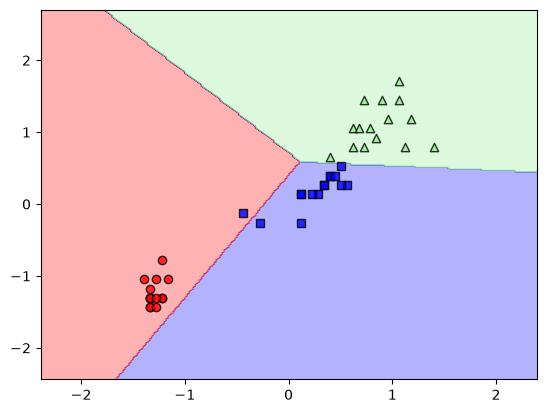

In [36]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X = X_test_std, y = y_test,
                      classifier= ppn)

plt.show()